In [ ]:
# Step 1 — Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Step 2 — Load Dataset
# Load dataset

df = pd.read_csv('/content/drive/MyDrive/GenAI_learning_April_2026/credit_card_frauds.csv')

# First 5 rows
print(df.head())

  trans_date_trans_time                   merchant       category     amt  \
0   2019-01-01 00:00:44  Heller, Gutmann and Zieme    grocery_pos  107.23   
1   2019-01-01 00:00:51             Lind-Buckridge  entertainment  220.11   
2   2019-01-01 00:07:27                  Kiehn Inc    grocery_pos   96.29   
3   2019-01-01 00:09:03                Beier-Hyatt   shopping_pos    7.77   
4   2019-01-01 00:21:32                 Bruen-Yost       misc_pos    6.85   

                       city state      lat      long  city_pop  \
0                    Orient    WA  48.8878 -118.2105       149   
1                Malad City    ID  42.1808 -112.2620      4154   
2                   Grenada    CA  41.6125 -122.5258       589   
3  High Rolls Mountain Park    NM  32.9396 -105.8189       899   
4                   Freedom    WY  43.0172 -111.0292       471   

                                 job         dob  \
0  Special educational needs teacher  1978-06-21   
1        Nature conservation officer

In [ ]:
# Step 3 — Understand the Dataset
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(339607, 15)
Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    33

In [ ]:
# Step 4 — Check Missing Values

missing_values = df.isnull().sum()
print(missing_values)

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [ ]:
df.columns

df = df.rename(columns={'is_fraud': 'Class'})
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'Class'],
      dtype='object')

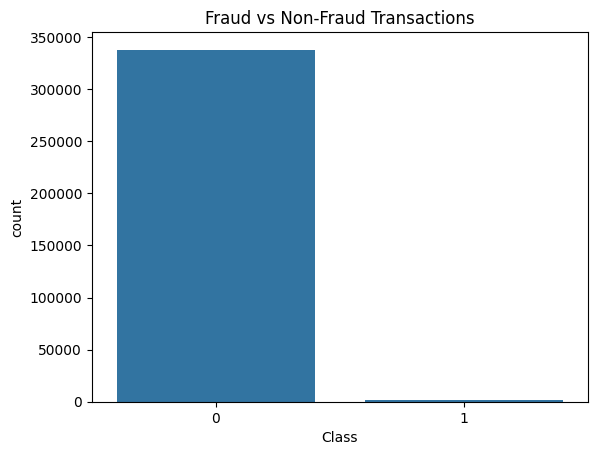

In [ ]:
# Step 5 — Visualize Class Distribution
sns.countplot(x=df['Class'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()


In [ ]:
# Step 6 — Feature and Target Separation

X = df.drop('Class', axis=1)
y = df['Class']

### Consolidated Feature Engineering

This step combines date/time feature extraction and label encoding for categorical features to ensure `X` is fully numerical before imputation.

In [ ]:
# Consolidated Feature Engineering

# Convert date columns to datetime objects (from old 38e6b5ee)
X['trans_date_trans_time'] = pd.to_datetime(X['trans_date_trans_time'])
X['dob'] = pd.to_datetime(X['dob'])

# Extract features from trans_date_trans_time
X['trans_hour'] = X['trans_date_trans_time'].dt.hour
X['trans_day_of_week'] = X['trans_date_trans_time'].dt.dayofweek
X['trans_month'] = X['trans_date_trans_time'].dt.month
X['trans_day_of_year'] = X['trans_date_trans_time'].dt.dayofyear

# Calculate age from dob at the time of transaction
# For simplicity, using the latest transaction date for age calculation
latest_transaction_date = X['trans_date_trans_time'].max()
X['age'] = ((latest_transaction_date - X['dob']).dt.days // 365)

# Drop original datetime columns and 'trans_num' (transaction ID)
X = X.drop(columns=['trans_date_trans_time', 'dob', 'trans_num'])

print("X after datetime feature engineering:")
print(X.head())
print(X.info())

# Label Encode Categorical Features (from old 67580ee3)
categorical_cols = ['merchant', 'category', 'city', 'state', 'job']

# Initialize LabelEncoder
encoder = LabelEncoder()

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    X[col] = encoder.fit_transform(X[col])

print("\nX after label encoding:")
print(X.head())
print(X.info())

X after datetime feature engineering:
                    merchant       category     amt                      city  \
0  Heller, Gutmann and Zieme    grocery_pos  107.23                    Orient   
1             Lind-Buckridge  entertainment  220.11                Malad City   
2                  Kiehn Inc    grocery_pos   96.29                   Grenada   
3                Beier-Hyatt   shopping_pos    7.77  High Rolls Mountain Park   
4                 Bruen-Yost       misc_pos    6.85                   Freedom   

  state      lat      long  city_pop                                job  \
0    WA  48.8878 -118.2105       149  Special educational needs teacher   
1    ID  42.1808 -112.2620      4154        Nature conservation officer   
2    CA  41.6125 -122.5258       589                    Systems analyst   
3    NM  32.9396 -105.8189       899                    Naval architect   
4    WY  43.0172 -111.0292       471          Education officer, museum   

   merch_lat  merch_long

In [ ]:
# find count of unique values for each columns
for col in X.columns:
    print(col, X[col].nunique())

merchant 693
category 14
amt 32112
city 176
state 13
lat 183
long 183
city_pop 174
job 163
merch_lat 335608
merch_long 337263
trans_hour 24
trans_day_of_week 7
trans_month 12
trans_day_of_year 366
age 67


### Feature Engineering

To prevent the loss of information from non-numerical columns, we will now perform feature engineering steps. This includes extracting features from date/time columns and one-hot encoding categorical variables.

In [ ]:
# Step 7 — Date and Time Feature Engineering (Moved)

# This step has been consolidated into the new 'Consolidated Feature Engineering' cell.

In [ ]:
# Label Encode Categorical Features

categorical_cols = ['merchant', 'category', 'city', 'state', 'job']

# Initialize LabelEncoder
encoder = LabelEncoder()

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    X[col] = encoder.fit_transform(X[col])

print("\nX after label encoding:")
print(X.head())
print(X.info())


X after label encoding:
   merchant  category     amt  city  state      lat      long  city_pop  job  \
0       241         4  107.23   116     11  48.8878 -118.2105       149  139   
1       390         0  220.11    93      5  42.1808 -112.2620      4154  101   
2       308         4   96.29    51      2  41.6125 -122.5258       589  143   
3        42        12    7.77    55      8  32.9396 -105.8189       899  102   
4        82         9    6.85    46     12  43.0172 -111.0292       471   45   

   merch_lat  merch_long  trans_hour  trans_day_of_week  trans_month  \
0  49.159047 -118.186462           0                  1            1   
1  43.150704 -112.154481           0                  1            1   
2  41.657520 -122.230347           0                  1            1   
3  32.863258 -106.520205           0                  1            1   
4  43.753735 -111.454923           0                  1            1   

   trans_day_of_year  age  
0                  1   42  
1    

In [ ]:
len(X.columns)
X.columns

Index(['merchant', 'category', 'amt', 'city', 'state', 'lat', 'long',
       'city_pop', 'job', 'merch_lat', 'merch_long', 'trans_hour',
       'trans_day_of_week', 'trans_month', 'trans_day_of_year', 'age'],
      dtype='object')

In [ ]:
len(X.columns)

16

In [ ]:
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Convert the imputed array back to a DataFrame to maintain column names and index
X_imputed = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

In [ ]:
# Step 8 — Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [ ]:
# Step 9 — Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(271685, 16)
(67922, 16)


In [ ]:
# Step 10 — Train Logistic Regression Model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Step 11 — Predictions
y_pred_log = log_model.predict(X_test)

In [ ]:
# Step 12 — Evaluate Logistic Regression

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

Accuracy: 0.994346456229204
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


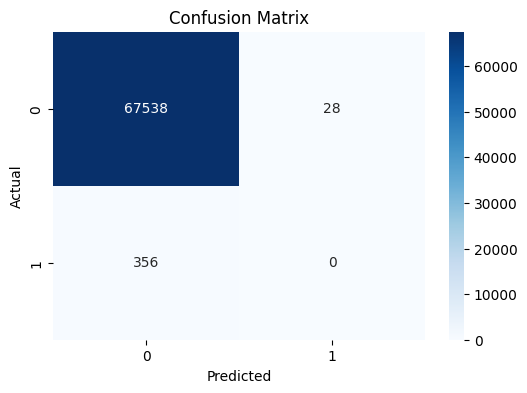

In [ ]:
# Step 13 — Confusion Matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Step 14 — Classification Report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     67566
           1       0.00      0.00      0.00       356

    accuracy                           0.99     67922
   macro avg       0.50      0.50      0.50     67922
weighted avg       0.99      0.99      0.99     67922



In [ ]:
# Step 15 — ROC AUC Score
y_prob = log_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print('ROC AUC Score:', roc_auc)

ROC AUC Score: 0.8054832029406452


In [ ]:
# Step 16 — Train Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Step 17 — Random Forest Predictions

y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Step 18 — Evaluate Random Forest

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

Accuracy: 0.998292158652572
Precision: 0.98
Recall: 0.6882022471910112
F1 Score: 0.8085808580858086


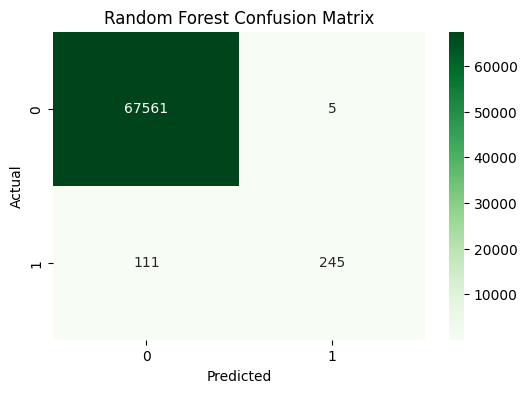

In [ ]:
# Step 19 — Random Forest Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
# Step 20 — Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

              Feature  Importance
2                 amt    0.366374
1            category    0.151852
11         trans_hour    0.107774
15                age    0.055268
14  trans_day_of_year    0.040035
9           merch_lat    0.039834
10         merch_long    0.039438
0            merchant    0.032600
7            city_pop    0.029189
3                city    0.025725


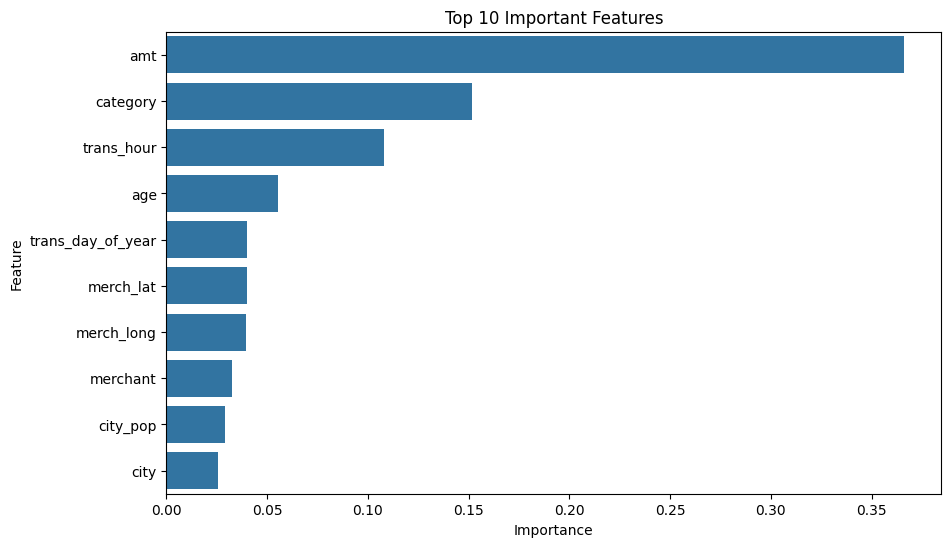

In [ ]:
# Step 21 — Visualize Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.show()